# Подключение библиотек

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Подгрузка датасета

In [98]:
ds=pd.read_csv("dataset.csv")
ds.head()

,text_id,label,source_model,domain,text_content,topic_hint,word_count,avg_sentence_length,generation_method
0,TXT_0001,human,human,social,can we talk about gene editing ethics for a se...,gene editing ethics,27,13.5,template+human_variation
1,TXT_0002,human,human,social,update on election integrity concerns: it's co...,election integrity concerns,20,10.0,template+human_variation
2,TXT_0003,ai,gemini-2.0,news,Analysts are closely watching developments rel...,climate change adaptation strategies,39,13.0,style_simulation
3,TXT_0004,human,human,academic,This paper examines genomic research breakthro...,genomic research breakthroughs,49,16.3,template+human_variation
4,TXT_0005,ai,gpt-4o,academic,Existing literature on student debt crisis has...,student debt crisis,42,10.8,style_simulation


# Анализ данных

## Проверка на дублирование текстов

In [99]:
ds["text_content"].duplicated().sum()

np.int64(1034)

Удаление дубликатов

In [100]:
ds = ds.drop_duplicates(subset=["text_content"])

Повторная проверка

In [101]:
ds["text_content"].duplicated().sum()

np.int64(0)

## Анализ баланса классов

In [102]:
ds["label"].value_counts()

label
human    579
ai       387
Name: count, dtype: int64

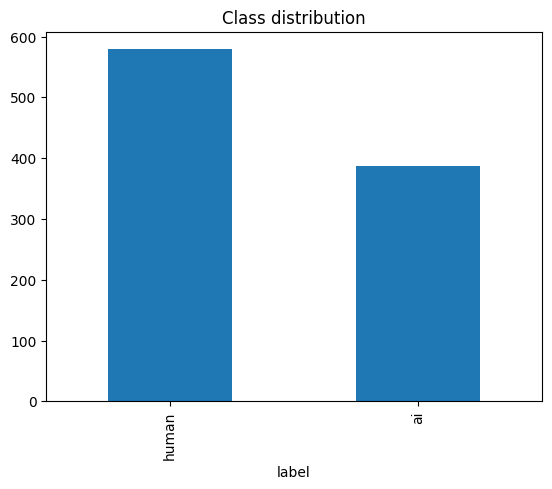

In [103]:
ds["label"].value_counts().plot(kind="bar")
plt.title("Class distribution")
plt.show()

Наблюдается умеренный дисбаланс данных, поэтому в качестве основной метрики используется Macro F1-Score вместо Accuracy

## Анализ длины текстов

<Axes: xlabel='word_count', ylabel='Count'>

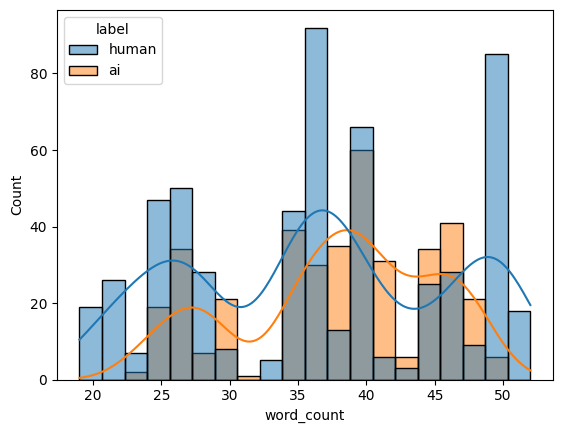

In [104]:
sns.histplot(data=ds, x='word_count', hue='label', bins=20, kde=True)

Тексты, сгенерированные ИИ, обладают более стабильной длиной, тогда как человеческие тексты демонстрируют большую вариативность

## Анализ длины предложений

<Axes: xlabel='avg_sentence_length', ylabel='Count'>

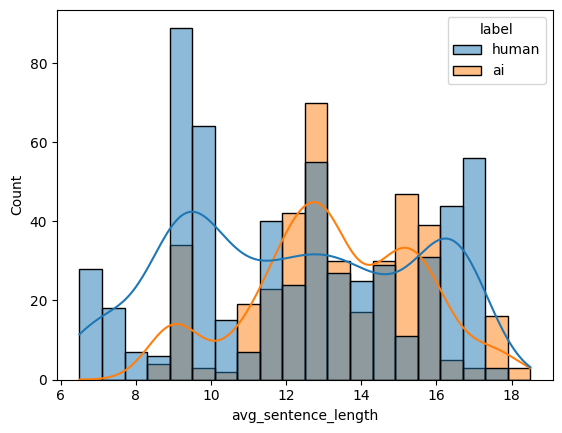

In [105]:
sns.histplot(data=ds, x='avg_sentence_length', hue='label', bins=20, kde=True)

Тексты, сгенерированные ИИ, характеризуются стабильной структурой предложений, тогда как человеческие тексты демонстрируют большую вариативность

## Выбор данных для модели

In [106]:
x = ds['text_content']
y = ds['label']

Разделение входного датасета на обучающую и тестовую выборки.

In [107]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

Векторизация текстов через TF-IDF

In [108]:
vectorizer = TfidfVectorizer()

x_train_vec = vectorizer.fit_transform(x_train)
x_test_vec = vectorizer.transform(x_test)

# Обучение модели

In [109]:
model = LogisticRegression(class_weight="balanced")
model.fit(x_train_vec, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

# Метрики


Предсказания модели

In [113]:
y_pred = model.predict(x_test_vec)

In [114]:
cr=classification_report(y_test, y_pred)
print(cr)

              precision    recall  f1-score   support

          ai       1.00      1.00      1.00        78
       human       1.00      1.00      1.00       116

    accuracy                           1.00       194
   macro avg       1.00      1.00      1.00       194
weighted avg       1.00      1.00      1.00       194



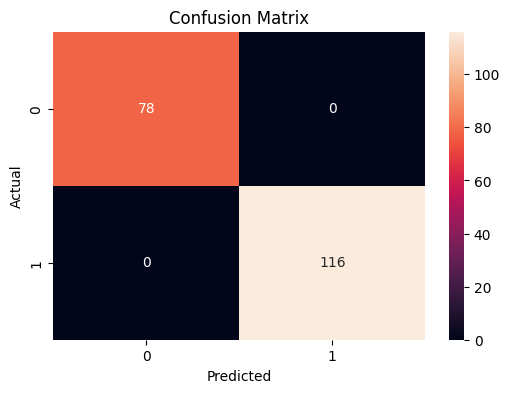

In [115]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Полученные результаты свидетельствуют о высокой разделимости классов в датасете. Использование TF-IDF и логистической регрессии позволило успешно классифицировать тексты на сгенерированные ИИ и написанные человеком.